In [1]:
from get_stock_data import get_combined_tech_stocks
from get_normalized_price import get_normalized_prices
import numpy as np
import pandas as pd
from datetime import date, timedelta, datetime
import matplotlib.pyplot as plt
import seaborn as sns
from get_top_matches import get_top_matches
import pickle

In [2]:
tech_tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META"]
data = get_combined_tech_stocks(tech_tickers)

Fetching data from 2011-07-12 to 2026-07-08...


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


In [5]:
def get_history_and_target_price(target_ticker, window=50):
    target_price = get_normalized_prices(data, target_ticker)[:window]
    history_prices = {}
    for ticker in data.keys():
        history_prices[ticker] = get_normalized_prices(data, ticker)[window:]
    return target_price, history_prices

In [76]:
target_price, historical_prices = get_history_and_target_price("AAPL", 50)

In [77]:
top_matches = get_top_matches(target_price[0], historical_prices, 50, 10)

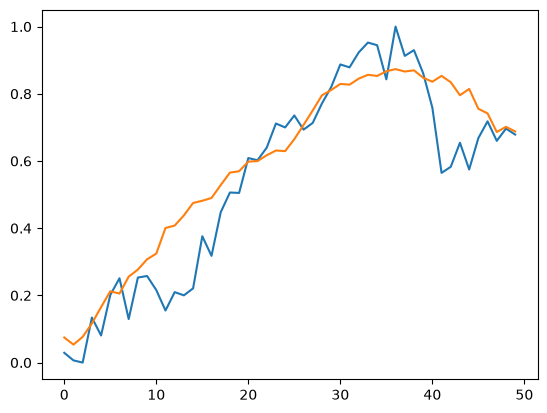

In [95]:
plt.plot(target_price[0][:50][::-1])

a = top_matches[0]["prices"]
for e in top_matches[1:]:
    a = [x + y for x, y in zip(a, e["prices"])]

a = [x / 11 for x in a]
plt.plot(a[::-1])


In [79]:
top_matches[0]

{'historical_ticker': 'NVDA',
 'historical_dates_end': '2021-07-26',
 'historical_dates_start': '2021-05-14',
 'dtw_distance': np.float64(1.934527456574686),
 'future_change_%': np.float64(0.27),
 'prices': [0.7899333696845933,
  0.8294180433967707,
  0.8348029669261674,
  0.8072827566645326,
  0.6879280553858242,
  0.7130184307750109,
  0.6204725454107202,
  0.7409120658828938,
  0.8718206348393944,
  0.9329193445221634,
  0.9721801348847143,
  0.903043069380678,
  0.8809818385712411,
  0.951128523625126,
  1.0,
  0.9683666837557618,
  0.9272356239297275,
  0.8959011047485287,
  0.8995287012449688,
  0.893283699662345,
  0.7505970937482219,
  0.7766962308966456,
  0.7545229154472934,
  0.7290210864947445,
  0.6602957604842743,
  0.6919287907983086,
  0.6946960233113176,
  0.5680129309075396,
  0.5647593311177554,
  0.599197622661913,
  0.5702557674266596,
  0.5103914184339774,
  0.5004081653660178,
  0.5145797240601975,
  0.5388043027920798,
  0.5327111301477087,
  0.4417201332320378,

In [106]:
matches_with_futures = []
for e in top_matches:
    ticker = e["historical_ticker"]
    df = data[ticker]
    df["Date"] = pd.to_datetime(df["Date"])
    historical_dates_start = pd.to_datetime(e["historical_dates_start"])
    historical_dates_end = pd.to_datetime(e["historical_dates_end"])

    price = list(df.loc[(df["Date"] >= historical_dates_start) & (df["Date"] <= historical_dates_end + timedelta(days=7))]["Close"])

    price = np.array(price)

    normalized_price = (price - np.min(price[:50])) / (np.max(price[:50]) - np.min(price[:50]))

    normalized_price = normalized_price[::-1]

    matches_with_futures.append(normalized_price)

In [113]:
ticker = "AAPL"
df = data[ticker]
df["Date"] = pd.to_datetime(df["Date"])
historical_dates_start = target_price[0][-2][1]
historical_dates_end = target_price[0][-2][0]

price = list(df.loc[(df["Date"] >= historical_dates_start) & (df["Date"] <= historical_dates_end + timedelta(days=7))]["Close"])

price = np.array(price)

normalized_price = (price - np.min(price[:50])) / (np.max(price[:50]) - np.min(price[:50]))

normalized_price = normalized_price[::-1]

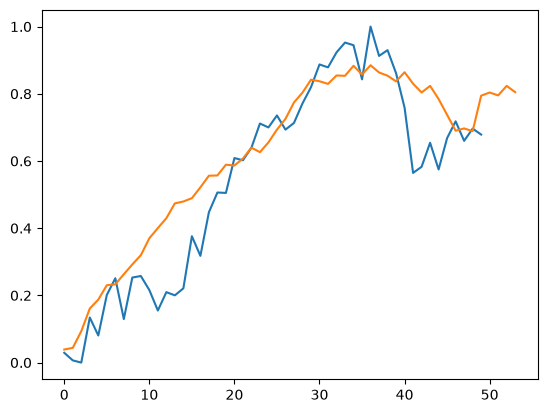

In [116]:
plt.plot(target_price[0][:50][::-1])

a = matches_with_futures[0]
for e in matches_with_futures[1:]:
    a = [x + y for x, y in zip(a, e)]

a = [x / 11 for x in a]

plt.plot(a[::-1])

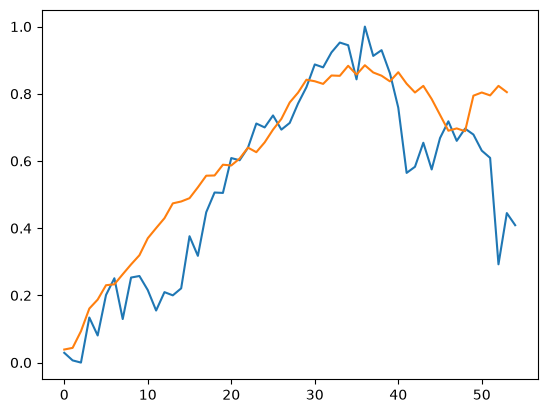

In [117]:
plt.plot(normalized_price[::-1])

a = matches_with_futures[0]
for e in matches_with_futures[1:]:
    a = [x + y for x, y in zip(a, e)]

a = [x / 11 for x in a]

plt.plot(a[::-1])